# Problem

**10×10 Gridworld**

**Layout (row-major indices)**

Legend: **S** start, **G** goal (terminal), **P** pit (terminal), **#** wall, **.** empty

```

r\c 0 1 2 3 4 5 6 7 8 9

0 S . . . # . . . . .

1 . # . . # . . # P .

2 . # # . . . . # . .

3 . . P . # . . # . .

4 # . # # # # # # . #

5 . . . . # . . P . .

6 . P # . # . # . . .

7 . . # . . P # . . .

8 . . # . # . # # . .

9 . . . . # . . . . G
```

**State space**

$$
\mathcal{X}={0,1,\dots,99},\quad x=10r+c
$$

* **Goal (absorbing):** $x_G=99$
* **Pits (absorbing):**
  $
  \mathcal{X}_{\text{pit}}={18,32,57,61,75,88}
  $
* **Walls (impassable):**
  $
  \mathcal{X}_{\text{wall}}={4,11,14,17,21,22,27,34,37,40,42,43,44,45,46,47,49,54,62,64,66,72,76,82,84,86,87,94}
  $

Terminal set:
$
\mathcal{T}={99}\cup \mathcal{X}_{\text{pit}}
$

**Action space**

$$
\mathcal{A}={0,1,2,3}
$$
where (0=) Up, (1=) Down, (2=) Left, (3=) Right.

**Transition dynamics (deterministic)**

Let $x\mapsto(r,c)$ by $r=\lfloor x/10\rfloor,\ c=x\bmod 10$.

* If $x\in\mathcal{T}$, then $\text{next\_state}(x,a)=x$ $absorbing$.
* Otherwise, compute the intended neighbor $(r',c')$ from action $a$.
* If $(r',c')$ is outside the grid, **stay**.
* Let $x'=10r'+c'$. If $x'\in\mathcal{X}_{\text{wall}}$, **stay**.

Transition matrix shape:
$$
P\in\mathbb{R}^{(|\mathcal{X}||\mathcal{A}|)\times|\mathcal{X}|}=\mathbb{R}^{400\times 100},
$$
with
$$
P[(x,a),x']=1 \iff x'=\text{next\_state}(x,a)
$$

**Reward model (standard step cost + terminal outcomes)**

Reward based on the **next state**:
$$
r(x,a)=
\begin{cases}
+1 & \text{if } \text{next\_state}(x,a)=99,\
-5 & \text{if } \text{next\_state}(x,a)\in \mathcal{X}_{\text{pit}},\
-0.1 & \text{otherwise.}
\end{cases}
$$

**Initial state**

$$
x_0=0.
$$

In [1]:
%load_ext autoreload
%autoreload 2

import os
import time
import sys
import random
import itertools
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.cluster import KMeans
from tqdm import tqdm


def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "10grid_rbf"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "grids").mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root found at: {PROJECT_ROOT}")

DATASET_PATH = DATASETS_DIR / "10grid_tabular.csv"
print(f"Loading dataset from: {DATASET_PATH}")


from rl_methods.mdp import DiscreteMDP, Planner
from rl_methods.data_collection import DiscreteDataBuffer, DatasetAnalyzer
from rl_methods.fogas import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)

from rl_methods.fqi import FQISolver

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project root found at: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Loading dataset from: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets/10grid_tabular.csv
Using device: cpu


/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# RBF Features

## With goal - pit condition feature

In [6]:
# ===== 10x10 Four-Rooms Grid Configuration =====
states = torch.arange(100, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

N, A = 100, 4
gamma = 0.9
x0 = 0

goal = 99
pits = {18, 32, 57, 61, 75}
walls = {
    4, 11, 14, 17, 21, 22, 27, 34, 37,
    40, 42, 43, 44, 45, 46, 47, 49,
    54, 62, 64, 66, 72, 76, 82, 84, 86, 87, 94,
}

terminal_states = {goal, *pits}

GRID_SIZE = 10
DTYPE = torch.float64


def state_to_coord(s, grid_size=GRID_SIZE):
    return divmod(int(s), grid_size)


def get_norm_coords(s, grid_size=GRID_SIZE, dtype=DTYPE):
    r, c = state_to_coord(s, grid_size)
    scale = grid_size - 1
    return torch.tensor([r / scale, c / scale], dtype=dtype)


def state_pool(excluded_states=None, grid_size=GRID_SIZE):
    excluded_states = set(excluded_states or [])
    return [
        s for s in range(grid_size * grid_size)
        if s not in excluded_states
    ]


def normalized_state_coords(state_ids, grid_size=GRID_SIZE):
    scale = grid_size - 1
    return [
        [
            state_to_coord(s, grid_size)[0] / scale,
            state_to_coord(s, grid_size)[1] / scale,
        ]
        for s in state_ids
    ]


def calculate_local_sigma(centers, k=2):
    if len(centers) <= k:
        raise ValueError("k must be smaller than the number of centers")

    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)

    # Same behavior as your old code: use nearest non-self distance.
    return torch.mean(topk_dists[:, 1])


def fit_kmeans_centers(
    num_centers,
    excluded_states=None,
    grid_size=GRID_SIZE,
    random_state=42,
):
    pool = state_pool(
        excluded_states=excluded_states,
        grid_size=grid_size,
    )

    if num_centers > len(pool):
        raise ValueError(
            f"num_centers={num_centers} but only {len(pool)} states are available"
        )

    kmeans = KMeans(
        n_clusters=num_centers,
        n_init=10,
        random_state=random_state,
    )
    kmeans.fit(normalized_state_coords(pool, grid_size=grid_size))

    return torch.tensor(kmeans.cluster_centers_, dtype=DTYPE)


def rbf_activations(state, centers, sigmas):
    coords = get_norm_coords(state, dtype=centers.dtype)
    dist_sq = torch.sum((coords - centers) ** 2, dim=1)

    sigmas = torch.as_tensor(
        sigmas,
        dtype=centers.dtype,
        device=centers.device,
    )

    if sigmas.ndim == 0:
        sigmas = sigmas.expand_as(dist_sq)

    return torch.exp(-dist_sq / (2 * sigmas ** 2))


def action_coupled_features(phi_state_fn, n_actions=A, dtype=DTYPE):
    def phi_fn(x, a):
        state_features = phi_state_fn(x)

        action_features = torch.zeros(n_actions, dtype=dtype)
        action_features[int(a)] = 1.0

        return torch.kron(action_features, state_features)

    return phi_fn


def build_kmeans_indicator_features(
    num_centers=30,
    excluded_states=None,
    k=2,
):
    excluded_states = walls if excluded_states is None else set(excluded_states)

    centers = fit_kmeans_centers(
        num_centers,
        excluded_states=excluded_states,
    )

    sigma = calculate_local_sigma(centers, k=k)
    sigmas = torch.full((len(centers),), float(sigma), dtype=DTYPE)

    def phi_state_fn(x):
        rbf = rbf_activations(x, centers, sigmas)

        indicators = torch.tensor(
            [int(x) in pits, int(x) == goal],
            dtype=DTYPE,
        )

        return torch.cat([
            rbf,
            torch.ones(1, dtype=DTYPE),
            indicators,
        ])

    return {
        "centers": centers,
        "sigmas": sigmas,
        "sigma": sigma,
        "phi_state": phi_state_fn,
        "phi": action_coupled_features(phi_state_fn),
    }


def next_state(x, a):
    x = int(x)
    a = int(a)

    if x in terminal_states:
        return x

    r, c = state_to_coord(x)

    if a == 0:
        r_next, c_next = max(0, r - 1), c
    elif a == 1:
        r_next, c_next = min(GRID_SIZE - 1, r + 1), c
    elif a == 2:
        r_next, c_next = r, max(0, c - 1)
    elif a == 3:
        r_next, c_next = r, min(GRID_SIZE - 1, c + 1)
    else:
        raise ValueError(f"Invalid action: {a}")

    xp = r_next * GRID_SIZE + c_next

    if xp in walls:
        return x

    return xp


# -----------------------------------------------------------------------
# Reward vector and transition matrix for DiscreteMDP
# -----------------------------------------------------------------------

P = torch.zeros((N * A, N), dtype=DTYPE)
r = torch.zeros(N * A, dtype=DTYPE)

for x in range(N):
    for a in range(A):
        idx = x * A + a
        xp = next_state(x, a)

        P[idx, xp] = 1.0

        # Same reward semantics used in the current fogas scripts:
        # reward is based on the transition destination.
        if x in terminal_states:
            r[idx] = 0.0
        elif xp == goal:
            r[idx] = 1.0
        elif xp in pits:
            r[idx] = -5.0
        else:
            r[idx] = -0.1

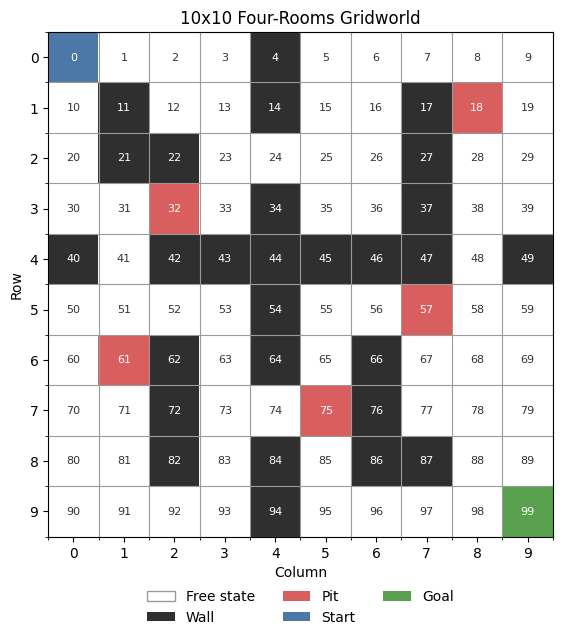

In [ ]:
def plot_four_rooms_grid(
    grid_size=10,
    start=0,
    goal=99,
    pits=None,
    walls=None,
    centers=None,
    show_state_ids=True,
    figsize=(6.5, 6.5),
    save_path=None,
):
    pits = set(pits or [])
    walls = set(walls or [])

    # Codes:
    # 0 = free, 1 = wall, 2 = pit, 3 = start, 4 = goal
    grid = np.zeros((grid_size, grid_size), dtype=int)

    for s in walls:
        r, c = divmod(int(s), grid_size)
        grid[r, c] = 1

    for s in pits:
        r, c = divmod(int(s), grid_size)
        grid[r, c] = 2

    sr, sc = divmod(int(start), grid_size)
    gr, gc = divmod(int(goal), grid_size)
    grid[sr, sc] = 3
    grid[gr, gc] = 4

    cmap = ListedColormap([
        "#ffffff",  # free
        "#2f2f2f",  # wall
        "#d95f5f",  # pit
        "#4c78a8",  # start
        "#59a14f",  # goal
    ])
    norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid, cmap=cmap, norm=norm)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#9a9a9a", linewidth=0.8)

    # Axis ticks
    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    # Put row 0 at the top, matching divmod indexing
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)

    if show_state_ids:
        for s in range(grid_size * grid_size):
            r, c = divmod(s, grid_size)

            if s in walls:
                color = "white"
            elif s in pits or s == start or s == goal:
                color = "white"
            else:
                color = "#333333"

            ax.text(
                c,
                r,
                str(s),
                ha="center",
                va="center",
                fontsize=8,
                color=color,
            )

    # Optional: plot k-means/RBF centers if passed in normalized coordinates
    if centers is not None:
        centers_np = centers.detach().cpu().numpy() if hasattr(centers, "detach") else np.asarray(centers)

        # Your centers are [row_normalized, col_normalized]
        rows = centers_np[:, 0] * (grid_size - 1)
        cols = centers_np[:, 1] * (grid_size - 1)

        ax.scatter(
            cols,
            rows,
            s=45,
            marker="x",
            linewidths=1.8,
            color="#f28e2b",
            label="RBF centers",
            zorder=5,
        )

    legend_items = [
        Patch(facecolor="#ffffff", edgecolor="#9a9a9a", label="Free state"),
        Patch(facecolor="#2f2f2f", label="Wall"),
        Patch(facecolor="#d95f5f", label="Pit"),
        Patch(facecolor="#4c78a8", label="Start"),
        Patch(facecolor="#59a14f", label="Goal"),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
    )

    ax.set_title("10x10 Four-Rooms Gridworld")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

fig, ax = plot_four_rooms_grid(
    grid_size=GRID_SIZE,
    start=x0,
    goal=goal,
    pits=pits,
    walls=walls,
)

plt.show()

### FOGAS implementation

In [ ]:
# -----------------------------------------------------------------------
# MDP 1: KMeans RBFs + bias + explicit pit/goal indicators
# -----------------------------------------------------------------------

mdp1_features = build_kmeans_indicator_features(
    num_centers=30,
    excluded_states=walls,
    k=2,
)

centers = mdp1_features["centers"]
rbf_sigma = mdp1_features["sigma"]
rbf_sigmas = mdp1_features["sigmas"]
phi_state = mdp1_features["phi_state"]
phi = mdp1_features["phi"]

d = int(phi(states[0], actions[0]).shape[0])

mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x0,
    r=r,
    P=P,
    terminal_states=terminal_states,
)

planner = Planner(mdp)

print(f"MDP1: {len(centers)} KMeans centers + bias + pit/goal indicators")
print(f"  sigma = {float(rbf_sigma):.6f}")
print(f"  d = A * (K + bias + 2 indicators) = {A} * ({len(centers)} + 3) = {d}")
print(f"  P shape = {tuple(mdp.P.shape)}")
print(f"  r shape = {tuple(mdp.r.shape)}")
print(f"  optimal V(x0) = {planner.v_star[x0].item():.6f}")

MDP1: 30 KMeans centers + bias + pit/goal indicators
  sigma = 0.162732
  d = A * (K + bias + 2 indicators) = 4 * (30 + 3) = 132
  P shape = (400, 100)
  r shape = (400,)
  optimal V(x0) = -0.822741


### Solving it


Device: cuda
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets/10grid_tabular.csv (n=8000)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           8000
Feature norm bound R:     2.1801
Num states N:             100
Num actions A:            4
Feature dim d:            132
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      35190.98475590095
T (iterations):                35191

FOGAS Hyperparameters
---------------------
alpha:                        0.000035
rho:                            894.002169
eta:                            0.000000
D_theta:                    36.331804
beta (ridge):             0.000001
D_pi (derived):           45.308433


Known omega not provided. Estimating from dataset...
[FOGASSolver] omega estimated via regression (beta_omega=1.02e-06, n=8000)
Estimated omega (first 5 components): tensor([-0.0052,  

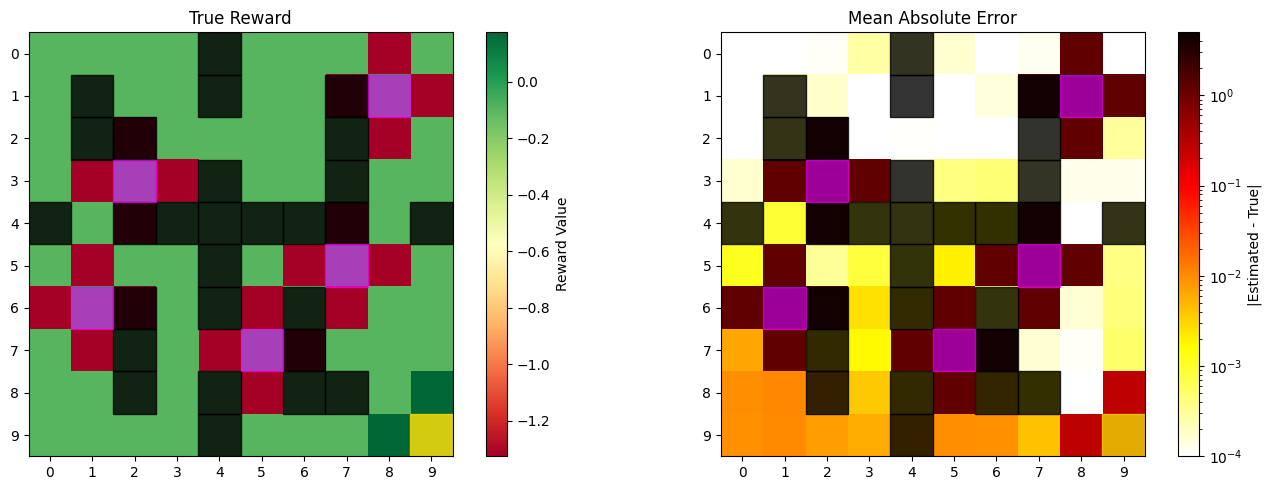

In [27]:
solver_e = FOGASSolver(
    mdp=mdp,
    phi=phi,
    csv_path=str(DATASET_PATH),
    device=device,
    seed=seed,
    print_params=True,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="greedy_average_return",
    metric_kwargs={
        "num_trajectories": 10,
        "max_steps": 50,
        "seed": seed,
        "terminal_states": terminal_states,
        "maximize": True,
    },
    seed=seed,
)

evaluator_e.analyze_reward_approximation(
    walls=walls,
    pits=pits,
    goal=goal,
)

In [28]:
# Run MDP1 solver with selected hyperparameters
solver_e.run(
    alpha=0.001 / 2,
    eta=0.0002,
    rho=0.05,
    T=13_000,
    tqdm_print=True,
)

# Print the learned solver policy
evaluator_e.print_solver_policy(policy_mode="solver")

# Optional: print the deterministic greedy version of the learned policy
evaluator_e.print_solver_policy(policy_mode="greedy")

# Print one sampled path from the learned policy
evaluator_e.print_optimal_path(
    policy_mode="greedy",
    goal_state=goal,
    terminal_states=terminal_states,
    max_steps=50,
    seed=seed,
)

FOGAS: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 13000/13000 [00:07<00:00, 1741.75it/s]

  State 0: pi(a=0|s=0) = 0.18  pi(a=1|s=0) = 0.19  pi(a=2|s=0) = 0.15  pi(a=3|s=0) = 0.47  --> best action: 3
  State 1: pi(a=0|s=1) = 0.10  pi(a=1|s=1) = 0.11  pi(a=2|s=1) = 0.05  pi(a=3|s=1) = 0.73  --> best action: 3
  State 2: pi(a=0|s=2) = 0.15  pi(a=1|s=2) = 0.33  pi(a=2|s=2) = 0.06  pi(a=3|s=2) = 0.46  --> best action: 3
  State 3: pi(a=0|s=3) = 0.13  pi(a=1|s=3) = 0.66  pi(a=2|s=3) = 0.07  pi(a=3|s=3) = 0.14  --> best action: 1
  State 4: pi(a=0|s=4) = 0.14  pi(a=1|s=4) = 0.53  pi(a=2|s=4) = 0.06  pi(a=3|s=4) = 0.28  --> best action: 1
  State 5: pi(a=0|s=5) = 0.09  pi(a=1|s=5) = 0.08  pi(a=2|s=5) = 0.03  pi(a=3|s=5) = 0.81  --> best action: 3
  State 6: pi(a=0|s=6) = 0.07  pi(a=1|s=6) = 0.02  pi(a=2|s=6) = 0.04  pi(a=3|s=6) = 0.87  --> best action: 3
  State 7: pi(a=0|s=7) = 0.10  pi(a=1|s=7) = 0.03  pi(a=2|s=7) = 0.10  pi(a=3|s=7) = 0.77  --> best action: 3
  State 8: pi(a=0|s=8) = 0.09  pi(a=1|s=8) = 0.33  pi(a=2|s=8) = 0.03  pi(a=3|s=8) = 0.55  --> best action: 3
  State 9:

### GRID search: FOGAS

In [ ]:
# -----------------------------------------------------------------------
# MDP1 center-count sweep: 100 down to 20
# Fixed FOGAS hyperparameters, MDP1 feature design
# -----------------------------------------------------------------------
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "10grid_rbf"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = RESULTS_DIR / "mdp1_center_sweep.csv"


# Fixed FOGAS hyperparameters
FOGAS_ALPHA = 0.001 / 2
FOGAS_ETA = 0.0002
FOGAS_RHO = 0.05
FOGAS_T = 13_000

# Sweep settings
START_CENTERS = 72
END_CENTERS = 20

NUM_TRAJECTORIES_GREEDY = 1
NUM_TRAJECTORIES_SOLVER = 10
MAX_STEPS = 50


def evaluate_fogas_center_count(num_centers):
    start_time = time.perf_counter()

    row = {
        "num_centers": int(num_centers),
        "feature_dim": None,
        "sigma": None,
        "status": "ok",
        "error": "",
        "elapsed_seconds": None,
        "solver_avg_reward": None,
        "greedy_avg_reward": None,
        "greedy_success_rate": None,
    }

    try:
        # ---------------------------------------------------------------
        # Build MDP1 features with this number of KMeans centers
        # ---------------------------------------------------------------
        mdp1_features = build_kmeans_indicator_features(
            num_centers=num_centers,
            excluded_states=walls,
            k=2,
        )

        centers_i = mdp1_features["centers"]
        sigma_i = mdp1_features["sigma"]
        phi_i = mdp1_features["phi"]

        d_i = int(phi_i(states[0], actions[0]).shape[0])

        row["feature_dim"] = d_i
        row["sigma"] = float(sigma_i)

        # ---------------------------------------------------------------
        # Same clean MDP dynamics/rewards, new feature map for FOGAS
        # ---------------------------------------------------------------
        mdp_i = DiscreteMDP(
            states=states,
            actions=actions,
            gamma=gamma,
            x0=x0,
            r=r,
            P=P,
            terminal_states=terminal_states,
        )

        planner_i = Planner(mdp_i)

        solver_i = FOGASSolver(
            mdp=mdp_i,
            phi=phi_i,
            csv_path=str(DATASET_PATH),
            device=device,
            seed=seed,
            print_params=False,
        )

        evaluator_i = FOGASEvaluator(
            solver=solver_i,
            mdp=mdp_i,
            planner=planner_i,
        )

        # ---------------------------------------------------------------
        # Train FOGAS with fixed hyperparameters
        # ---------------------------------------------------------------
        solver_i.run(
            alpha=FOGAS_ALPHA,
            eta=FOGAS_ETA,
            rho=FOGAS_RHO,
            T=FOGAS_T,
            tqdm_print=False,
        )

        # ---------------------------------------------------------------
        # Metrics
        # ---------------------------------------------------------------
        solver_avg_reward = evaluator_i.average_return(
            policy_mode="solver",
            num_trajectories=NUM_TRAJECTORIES_SOLVER,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        greedy_avg_reward = evaluator_i.average_return(
            policy_mode="greedy",
            num_trajectories=NUM_TRAJECTORIES_GREEDY,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        greedy_success_rate = evaluator_i.success_rate(
            goal_state=goal,
            policy_mode="greedy",
            num_trajectories=NUM_TRAJECTORIES_GREEDY,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        row["solver_avg_reward"] = float(solver_avg_reward)
        row["greedy_avg_reward"] = float(greedy_avg_reward)
        row["greedy_success_rate"] = float(greedy_success_rate)

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = repr(exc)

    finally:
        row["elapsed_seconds"] = float(time.perf_counter() - start_time)

    return row


results = []

for num_centers in range(START_CENTERS, END_CENTERS - 1, -1):
    print(f"\n[num_centers={num_centers}] running...")

    row = evaluate_fogas_center_count(num_centers)
    results.append(row)

    df_results = pd.DataFrame(results)
    df_results.to_csv(OUTPUT_CSV, index=False)

    if row["status"] == "ok":
        succeeded = row["greedy_success_rate"] >= 1.0
        status_text = "SUCCEEDED" if succeeded else "FAILED_TO_REACH_GOAL"

        print(
            f"  {status_text} | "
            f"d={row['feature_dim']} | "
            f"sigma={row['sigma']:.6f} | "
            f"solver_avg_reward={row['solver_avg_reward']:.6f} | "
            f"greedy_avg_reward={row['greedy_avg_reward']:.6f} | "
            f"greedy_success_rate={row['greedy_success_rate']:.2f} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )
    else:
        print(
            f"  ERROR | "
            f"{row['error']} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )

print(f"\nSaved center sweep results to: {OUTPUT_CSV}")


[num_centers=100] running...
  ERROR | ValueError('num_centers=100 but only 72 states are available') | time=0.0s

[num_centers=99] running...
  ERROR | ValueError('num_centers=99 but only 72 states are available') | time=0.0s

[num_centers=98] running...
  ERROR | ValueError('num_centers=98 but only 72 states are available') | time=0.0s

[num_centers=97] running...
  ERROR | ValueError('num_centers=97 but only 72 states are available') | time=0.0s

[num_centers=96] running...
  ERROR | ValueError('num_centers=96 but only 72 states are available') | time=0.0s

[num_centers=95] running...
  ERROR | ValueError('num_centers=95 but only 72 states are available') | time=0.0s

[num_centers=94] running...
  ERROR | ValueError('num_centers=94 but only 72 states are available') | time=0.0s

[num_centers=93] running...
  ERROR | ValueError('num_centers=93 but only 72 states are available') | time=0.0s

[num_centers=92] running...
  ERROR | ValueError('num_centers=92 but only 72 states are avail

  SUCCEEDED | d=300 | sigma=0.111111 | solver_avg_reward=-0.911866 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=13.6s

[num_centers=71] running...
[FOGASSolver] omega estimated via regression (beta_omega=4.56e-07, n=8000)
  SUCCEEDED | d=296 | sigma=0.111296 | solver_avg_reward=-0.911866 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=13.3s

[num_centers=70] running...
[FOGASSolver] omega estimated via regression (beta_omega=4.63e-07, n=8000)
  SUCCEEDED | d=292 | sigma=0.111486 | solver_avg_reward=-0.964490 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=13.2s

[num_centers=69] running...
[FOGASSolver] omega estimated via regression (beta_omega=4.69e-07, n=8000)
  SUCCEEDED | d=288 | sigma=0.111871 | solver_avg_reward=-0.962501 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=12.6s

[num_centers=68] running...
[FOGASSolver] omega estimated via regression (beta_omega=4.76e-07, n=8000)
  SUCCEEDED | d=284 | sigma=0.111883

Loaded 53 successful rows from: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/10grid_rbf/mdp1_center_sweep.csv


,num_centers,feature_dim,sigma,status,error,elapsed_seconds,solver_avg_reward,greedy_avg_reward,greedy_success_rate
52,20,92.0,0.215566,ok,NaN,7.460889,-1.147413,-0.994846,0.0
51,21,96.0,0.212911,ok,NaN,7.446090,-1.094063,-0.994846,0.0
50,22,100.0,0.203462,ok,NaN,7.418113,-1.143229,-0.994846,0.0
49,23,104.0,0.205215,ok,NaN,7.367387,-1.262607,-0.994846,0.0
48,24,108.0,0.186080,ok,NaN,7.301140,-1.072035,-0.994846,0.0


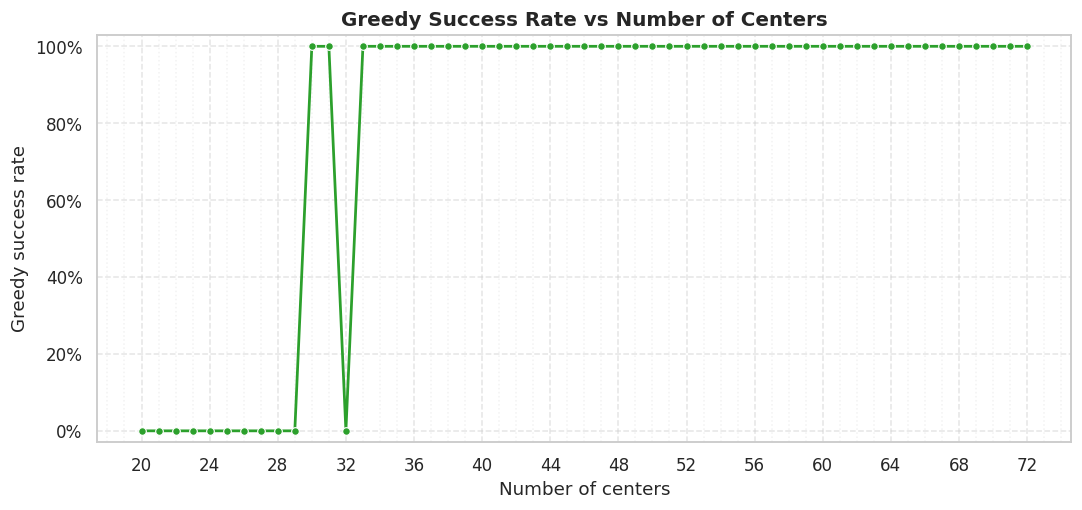

In [3]:
# ── Plot MDP1 Center Sweep: Greedy Success Rate ───────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter, MultipleLocator

CSV_PATH = RESULTS_DIR / "mdp1_center_sweep.csv"

df_centers = pd.read_csv(CSV_PATH)

if "status" in df_centers.columns:
    df_centers = df_centers[df_centers["status"].eq("ok")].copy()

df_centers["num_centers"] = pd.to_numeric(df_centers["num_centers"], errors="coerce")
df_centers["greedy_success_rate"] = pd.to_numeric(
    df_centers["greedy_success_rate"],
    errors="coerce",
)

df_centers = df_centers.dropna(
    subset=["num_centers", "greedy_success_rate"]
).copy()

df_centers = df_centers.sort_values("num_centers")

print(f"Loaded {len(df_centers)} successful rows from: {CSV_PATH}")
display(df_centers.head())

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

fig, ax = plt.subplots(figsize=(10, 4.8))

sns.lineplot(
    data=df_centers,
    x="num_centers",
    y="greedy_success_rate",
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="tab:green",
    ax=ax,
)

ax.set_title("Greedy Success Rate vs Number of Centers", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of centers")
ax.set_ylabel("Greedy success rate")

ax.set_ylim(-0.03, 1.03)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

# Show more numbers on the x-axis
ax.xaxis.set_major_locator(MultipleLocator(4))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", linestyle="--", alpha=0.5)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)

plt.tight_layout()
plt.show()

### GRID search: FQI

In [47]:
# -----------------------------------------------------------------------
# MDP1 center-count sweep for FQI: 72 down to 20
# Fixed FQI hyperparameters, MDP1 feature design
# -----------------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "10grid_rbf"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = RESULTS_DIR / "mdp1_center_sweep_fqi.csv"


# Fixed FQI hyperparameters
FQI_K = 4_000
FQI_TAU = 0.2
FQI_RIDGE = 1e-6
FQI_AUGMENT_TERMINAL_TRANSITIONS = True

# MDP1 excludes walls, so max valid centers is 100 - len(walls) = 72
START_CENTERS = 72
END_CENTERS = 20

NUM_TRAJECTORIES_GREEDY = 1
MAX_STEPS = 50


def evaluate_fqi_center_count(num_centers):
    start_time = time.perf_counter()

    row = {
        "num_centers": int(num_centers),
        "feature_dim": None,
        "sigma": None,
        "status": "ok",
        "error": "",
        "elapsed_seconds": None,
        "greedy_avg_reward": None,
        "greedy_success_rate": None,
    }

    try:
        # ---------------------------------------------------------------
        # Build MDP1 features with this number of KMeans centers
        # ---------------------------------------------------------------
        mdp1_features = build_kmeans_indicator_features(
            num_centers=num_centers,
            excluded_states=walls,
            k=2,
        )

        centers_i = mdp1_features["centers"]
        sigma_i = mdp1_features["sigma"]
        phi_i = mdp1_features["phi"]

        d_i = int(phi_i(states[0], actions[0]).shape[0])

        row["feature_dim"] = d_i
        row["sigma"] = float(sigma_i)

        # ---------------------------------------------------------------
        # Same clean MDP dynamics/rewards, new feature map for FQI
        # ---------------------------------------------------------------
        mdp_i = DiscreteMDP(
            states=states,
            actions=actions,
            gamma=gamma,
            x0=x0,
            r=r,
            P=P,
            terminal_states=terminal_states,
        )

        planner_i = Planner(mdp_i)

        solver_i = FQISolver(
            mdp=mdp_i,
            phi=phi_i,
            csv_path=str(DATASET_PATH),
            planner=planner_i,
            device=device,
            seed=seed,
            ridge=FQI_RIDGE,
            augment_terminal_transitions=FQI_AUGMENT_TERMINAL_TRANSITIONS,
        )

        evaluator_i = FOGASEvaluator(
            solver=solver_i,
            mdp=mdp_i,
            planner=planner_i,
        )

        # ---------------------------------------------------------------
        # Train FQI with fixed hyperparameters
        # ---------------------------------------------------------------
        solver_i.run(
            K=FQI_K,
            tau=FQI_TAU,
            verbose=False,
        )

        # ---------------------------------------------------------------
        # Metrics
        # FQI policy is greedy/deterministic, so "solver" and "greedy"
        # are effectively the same after run().
        # ---------------------------------------------------------------
        greedy_avg_reward = evaluator_i.average_return(
            policy_mode="greedy",
            num_trajectories=NUM_TRAJECTORIES_GREEDY,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        greedy_success_rate = evaluator_i.success_rate(
            goal_state=goal,
            policy_mode="greedy",
            num_trajectories=NUM_TRAJECTORIES_GREEDY,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        row["greedy_avg_reward"] = float(greedy_avg_reward)
        row["greedy_success_rate"] = float(greedy_success_rate)

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = repr(exc)

    finally:
        row["elapsed_seconds"] = float(time.perf_counter() - start_time)

    return row


results = []

for num_centers in range(START_CENTERS, END_CENTERS - 1, -1):
    print(f"\n[num_centers={num_centers}] running FQI...")

    row = evaluate_fqi_center_count(num_centers)
    results.append(row)

    pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)

    if row["status"] == "ok":
        succeeded = row["greedy_success_rate"] >= 1.0
        status_text = "SUCCEEDED" if succeeded else "FAILED_TO_REACH_GOAL"

        print(
            f"  {status_text} | "
            f"d={row['feature_dim']} | "
            f"sigma={row['sigma']:.6f} | "
            f"greedy_avg_reward={row['greedy_avg_reward']:.6f} | "
            f"greedy_success_rate={row['greedy_success_rate']:.2f} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )
    else:
        print(
            f"  ERROR | "
            f"{row['error']} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )

print(f"\nSaved FQI center sweep results to: {OUTPUT_CSV}")


[num_centers=72] running FQI...
  FAILED_TO_REACH_GOAL | d=300 | sigma=0.111111 | greedy_avg_reward=-0.994846 | greedy_success_rate=0.00 | time=7.0s

[num_centers=71] running FQI...
  FAILED_TO_REACH_GOAL | d=296 | sigma=0.111296 | greedy_avg_reward=-0.994846 | greedy_success_rate=0.00 | time=6.8s

[num_centers=70] running FQI...
  FAILED_TO_REACH_GOAL | d=292 | sigma=0.111486 | greedy_avg_reward=-0.994846 | greedy_success_rate=0.00 | time=6.8s

[num_centers=69] running FQI...
  FAILED_TO_REACH_GOAL | d=288 | sigma=0.111871 | greedy_avg_reward=-0.994846 | greedy_success_rate=0.00 | time=6.8s

[num_centers=68] running FQI...
  FAILED_TO_REACH_GOAL | d=284 | sigma=0.111883 | greedy_avg_reward=-0.994846 | greedy_success_rate=0.00 | time=6.7s

[num_centers=67] running FQI...
  FAILED_TO_REACH_GOAL | d=280 | sigma=0.112090 | greedy_avg_reward=-0.994846 | greedy_success_rate=0.00 | time=7.0s

[num_centers=66] running FQI...
  FAILED_TO_REACH_GOAL | d=276 | sigma=0.112303 | greedy_avg_reward

## Kmeans centers

In [49]:
# -----------------------------------------------------------------------
# MDP 2: General KMeans RBFs + bias
# -----------------------------------------------------------------------

def build_general_kmeans_features(
    num_centers=71,
    sigma_scale=0.1,
    excluded_states=None,
    normalize_rbf=True,
    k=2,
):
    """
    General KMeans RBF feature design:
    - KMeans centers only.
    - No explicit pit/goal indicators.
    - No anchored centers.
    - Sigma = local KNN sigma * sigma_scale.
    - Optional partition-of-unity RBF normalization.
    - Bias feature included.
    """
    centers = fit_kmeans_centers(
        num_centers,
        excluded_states=excluded_states,
    )

    base_sigma = calculate_local_sigma(centers, k=k)
    sigma = base_sigma * sigma_scale

    sigmas = torch.full(
        (len(centers),),
        float(sigma),
        dtype=DTYPE,
    )

    def phi_state_fn(x):
        rbf = rbf_activations(x, centers, sigmas)

        if normalize_rbf:
            total_activation = torch.sum(rbf)
            if total_activation > 1e-12:
                rbf = rbf / total_activation

        return torch.cat([
            rbf,
            torch.ones(1, dtype=DTYPE),
        ])

    return {
        "centers": centers,
        "sigmas": sigmas,
        "base_sigma": base_sigma,
        "sigma": sigma,
        "sigma_scale": sigma_scale,
        "normalize_rbf": normalize_rbf,
        "phi_state": phi_state_fn,
        "phi": action_coupled_features(phi_state_fn),
    }

### FOGAS

In [50]:
# -----------------------------------------------------------------------
# Create MDP2 with general KMeans features
# -----------------------------------------------------------------------

general_kmeans_features = build_general_kmeans_features(
    num_centers=70,
    sigma_scale=0.1,
    excluded_states=None,  
    normalize_rbf=True,     
    k=2,
)

centers2 = general_kmeans_features["centers"]
sigmas2 = general_kmeans_features["sigmas"]
base_sigma2 = general_kmeans_features["base_sigma"]
sigma2 = general_kmeans_features["sigma"]
sigma_scale2 = general_kmeans_features["sigma_scale"]
phi_state2 = general_kmeans_features["phi_state"]
phi2 = general_kmeans_features["phi"]

d2 = int(phi2(states[0], actions[0]).shape[0])

mdp2 = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x0,
    r=r,
    P=P,
    terminal_states=terminal_states,
)

planner2 = Planner(mdp2)

print("MDP2: general KMeans RBFs + bias")
print(f"  centers = {len(centers2)}")
print(f"  base_sigma = {float(base_sigma2):.6f}")
print(
    f"  sigma = base_sigma * sigma_scale = "
    f"{float(base_sigma2):.6f} * {sigma_scale2} = {float(sigma2):.6f}"
)
print(f"  normalize_rbf = {general_kmeans_features['normalize_rbf']}")
print(f"  d = A * (K + bias) = {A} * ({len(centers2)} + 1) = {d2}")
print(f"  P shape = {tuple(mdp2.P.shape)}")
print(f"  r shape = {tuple(mdp2.r.shape)}")
print(f"  optimal V(x0) = {planner2.v_star[x0].item():.6f}")

MDP2: general KMeans RBFs + bias
  centers = 70
  base_sigma = 0.115050
  sigma = base_sigma * sigma_scale = 0.115050 * 0.1 = 0.011505
  normalize_rbf = True
  d = A * (K + bias) = 4 * (70 + 1) = 284
  P shape = (400, 100)
  r shape = (400,)
  optimal V(x0) = -0.822741


### Solving it


Device: cuda
Dataset: /shared/home/mauro.diaz/work/FOGAS/data/datasets/10grid_tabular.csv (n=8000)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           8000
Feature norm bound R:     1.4142
Num states N:             100
Num actions A:            4
Feature dim d:            284
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      14808.205642224591
T (iterations):                14809

FOGAS Hyperparameters
---------------------
alpha:                        0.000057
rho:                            1863.733815
eta:                            0.000000
D_theta:                    53.291650
beta (ridge):             0.000000
D_pi (derived):           45.309638


Known omega not provided. Estimating from dataset...
[FOGASSolver] omega estimated via regression (beta_omega=4.76e-07, n=8000)
Estimated omega (first 5 components): tensor([-4.4936,

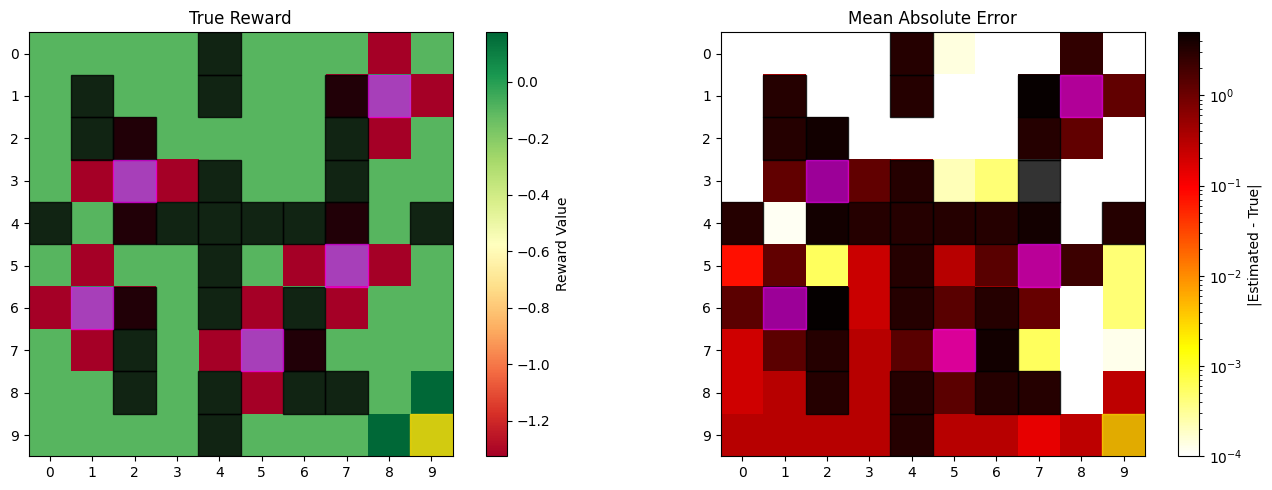

In [39]:
# -----------------------------------------------------------------------
# FOGAS solver for MDP2
# -----------------------------------------------------------------------

solver_e2 = FOGASSolver(
    mdp=mdp2,
    phi=phi2,
    csv_path=str(DATASET_PATH),
    device=device,
    seed=seed,
    print_params=True,
)

evaluator_e2 = FOGASEvaluator(
    solver=solver_e2,
    mdp=mdp2,
    planner=planner2,
)

optimizer_e2 = FOGASHyperOptimizer(
    solver=solver_e2,
    evaluator=evaluator_e2,
    metric="greedy_average_return",
    metric_kwargs={
        "num_trajectories": 10,
        "max_steps": 50,
        "seed": seed,
        "terminal_states": terminal_states,
        "maximize": True,
    },
    seed=seed,
)

evaluator_e2.analyze_reward_approximation(
    walls=walls,
    pits=pits,
    goal=goal,
)

In [40]:
# Run MDP2 solver with selected hyperparameters
solver_e2.run(
    alpha=0.001 / 2,
    eta=0.0002,
    rho=0.05,
    T=13_000,
    tqdm_print=True,
)

# Print the learned stochastic solver policy
evaluator_e2.print_solver_policy(policy_mode="solver")

# Print the deterministic greedy version
evaluator_e2.print_solver_policy(policy_mode="greedy")

# Print one sampled path from the learned greedy policy
evaluator_e2.print_optimal_path(
    policy_mode="greedy",
    goal_state=goal,
    terminal_states=terminal_states,
    max_steps=50,
    seed=seed,
)

FOGAS:   0%|                                                                                                            | 0/13000 [00:00<?, ?it/s]

FOGAS: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 13000/13000 [00:12<00:00, 1046.56it/s]


  State 0: pi(a=0|s=0) = 0.12  pi(a=1|s=0) = 0.16  pi(a=2|s=0) = 0.12  pi(a=3|s=0) = 0.60  --> best action: 3
  State 1: pi(a=0|s=1) = 0.12  pi(a=1|s=1) = 0.16  pi(a=2|s=1) = 0.12  pi(a=3|s=1) = 0.60  --> best action: 3
  State 2: pi(a=0|s=2) = 0.11  pi(a=1|s=2) = 0.69  pi(a=2|s=2) = 0.00  pi(a=3|s=2) = 0.20  --> best action: 1
  State 3: pi(a=0|s=3) = 0.20  pi(a=1|s=3) = 0.51  pi(a=2|s=3) = 0.10  pi(a=3|s=3) = 0.19  --> best action: 1
  State 4: pi(a=0|s=4) = 0.03  pi(a=1|s=4) = 0.40  pi(a=2|s=4) = 0.04  pi(a=3|s=4) = 0.52  --> best action: 3
  State 5: pi(a=0|s=5) = 0.12  pi(a=1|s=5) = 0.13  pi(a=2|s=5) = 0.14  pi(a=3|s=5) = 0.61  --> best action: 3
  State 6: pi(a=0|s=6) = 0.09  pi(a=1|s=6) = 0.07  pi(a=2|s=6) = 0.08  pi(a=3|s=6) = 0.76  --> best action: 3
  State 7: pi(a=0|s=7) = 0.07  pi(a=1|s=7) = 0.12  pi(a=2|s=7) = 0.08  pi(a=3|s=7) = 0.73  --> best action: 3
  State 8: pi(a=0|s=8) = 0.00  pi(a=1|s=8) = 0.00  pi(a=2|s=8) = 0.00  pi(a=3|s=8) = 1.00  --> best action: 3
  State 9:

### GRID search: FOGAS

In [ ]:
# -----------------------------------------------------------------------
# MDP2 center-count sweep for FOGAS: 100 down to 20
# General KMeans RBFs + bias
# -----------------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "10grid_rbf"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = RESULTS_DIR / "mdp2_general_kmeans_center_sweep_fogas.csv"


# Fixed MDP2 feature settings
SIGMA_SCALE = 0.1
NORMALIZE_RBF = True
EXCLUDED_STATES = None  # same as FQI-style setup: all grid states, including walls

# Fixed FOGAS hyperparameters
FOGAS_ALPHA = 0.001 / 2
FOGAS_ETA = 0.0002
FOGAS_RHO = 0.05
FOGAS_T = 13_000

# Sweep settings
START_CENTERS = 100
END_CENTERS = 20

NUM_TRAJECTORIES_SOLVER = 10
NUM_TRAJECTORIES_GREEDY = 1
MAX_STEPS = 50


def evaluate_fogas_general_kmeans_center_count(num_centers):
    start_time = time.perf_counter()

    row = {
        "num_centers": int(num_centers),
        "feature_dim": None,
        "base_sigma": None,
        "sigma": None,
        "sigma_scale": SIGMA_SCALE,
        "normalize_rbf": NORMALIZE_RBF,
        "status": "ok",
        "error": "",
        "elapsed_seconds": None,
        "solver_avg_reward": None,
        "greedy_avg_reward": None,
        "greedy_success_rate": None,
    }

    try:
        # ---------------------------------------------------------------
        # Build MDP2 general KMeans features
        # ---------------------------------------------------------------
        general_kmeans_features_i = build_general_kmeans_features(
            num_centers=num_centers,
            sigma_scale=SIGMA_SCALE,
            excluded_states=EXCLUDED_STATES,
            normalize_rbf=NORMALIZE_RBF,
            k=2,
        )

        centers_i = general_kmeans_features_i["centers"]
        base_sigma_i = general_kmeans_features_i["base_sigma"]
        sigma_i = general_kmeans_features_i["sigma"]
        phi_i = general_kmeans_features_i["phi"]

        d_i = int(phi_i(states[0], actions[0]).shape[0])

        row["feature_dim"] = d_i
        row["base_sigma"] = float(base_sigma_i)
        row["sigma"] = float(sigma_i)

        # ---------------------------------------------------------------
        # Same clean MDP dynamics/rewards, new feature map for FOGAS
        # ---------------------------------------------------------------
        mdp_i = DiscreteMDP(
            states=states,
            actions=actions,
            gamma=gamma,
            x0=x0,
            r=r,
            P=P,
            terminal_states=terminal_states,
        )

        planner_i = Planner(mdp_i)

        solver_i = FOGASSolver(
            mdp=mdp_i,
            phi=phi_i,
            csv_path=str(DATASET_PATH),
            device=device,
            seed=seed,
            print_params=False,
        )

        evaluator_i = FOGASEvaluator(
            solver=solver_i,
            mdp=mdp_i,
            planner=planner_i,
        )

        # ---------------------------------------------------------------
        # Train FOGAS with fixed hyperparameters
        # ---------------------------------------------------------------
        solver_i.run(
            alpha=FOGAS_ALPHA,
            eta=FOGAS_ETA,
            rho=FOGAS_RHO,
            T=FOGAS_T,
            tqdm_print=False,
        )

        # ---------------------------------------------------------------
        # Metrics
        # ---------------------------------------------------------------
        solver_avg_reward = evaluator_i.average_return(
            policy_mode="solver",
            num_trajectories=NUM_TRAJECTORIES_SOLVER,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        greedy_avg_reward = evaluator_i.average_return(
            policy_mode="greedy",
            num_trajectories=NUM_TRAJECTORIES_GREEDY,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        greedy_success_rate = evaluator_i.success_rate(
            goal_state=goal,
            policy_mode="greedy",
            num_trajectories=NUM_TRAJECTORIES_GREEDY,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        row["solver_avg_reward"] = float(solver_avg_reward)
        row["greedy_avg_reward"] = float(greedy_avg_reward)
        row["greedy_success_rate"] = float(greedy_success_rate)

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = repr(exc)

    finally:
        row["elapsed_seconds"] = float(time.perf_counter() - start_time)

    return row


results = []

for num_centers in range(START_CENTERS, END_CENTERS - 1, -1):
    print(f"\n[num_centers={num_centers}] running FOGAS with general KMeans features...")

    row = evaluate_fogas_general_kmeans_center_count(num_centers)
    results.append(row)

    pd.DataFrame(results).to_csv(OUTPUT_CSV, index=False)

    if row["status"] == "ok":
        succeeded = row["greedy_success_rate"] >= 1.0
        status_text = "SUCCEEDED" if succeeded else "FAILED_TO_REACH_GOAL"

        print(
            f"  {status_text} | "
            f"d={row['feature_dim']} | "
            f"base_sigma={row['base_sigma']:.6f} | "
            f"sigma={row['sigma']:.6f} | "
            f"solver_avg_reward={row['solver_avg_reward']:.6f} | "
            f"greedy_avg_reward={row['greedy_avg_reward']:.6f} | "
            f"greedy_success_rate={row['greedy_success_rate']:.2f} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )
    else:
        print(
            f"  ERROR | "
            f"{row['error']} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )

print(f"\nSaved FOGAS MDP2 general KMeans sweep results to: {OUTPUT_CSV}")


[num_centers=100] running FOGAS with general KMeans features...
[FOGASSolver] omega estimated via regression (beta_omega=3.34e-07, n=8000)
  SUCCEEDED | d=404 | base_sigma=0.111111 | sigma=0.011111 | solver_avg_reward=-1.161738 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=19.8s

[num_centers=99] running FOGAS with general KMeans features...
[FOGASSolver] omega estimated via regression (beta_omega=3.38e-07, n=8000)
  SUCCEEDED | d=400 | base_sigma=0.111244 | sigma=0.011124 | solver_avg_reward=-1.159749 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=19.3s

[num_centers=98] running FOGAS with general KMeans features...
[FOGASSolver] omega estimated via regression (beta_omega=3.41e-07, n=8000)
  SUCCEEDED | d=396 | base_sigma=0.111379 | sigma=0.011138 | solver_avg_reward=-1.006640 | greedy_avg_reward=-0.822741 | greedy_success_rate=1.00 | time=19.3s

[num_centers=97] running FOGAS with general KMeans features...
[FOGASSolver] omega estimated via regress

Loaded 81 successful rows from: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/10grid_rbf/mdp2_general_kmeans_center_sweep_fogas.csv


,num_centers,feature_dim,base_sigma,sigma,sigma_scale,normalize_rbf,status,error,elapsed_seconds,solver_avg_reward,greedy_avg_reward,greedy_success_rate
80,20,84,0.214575,0.021457,0.1,True,ok,NaN,7.468090,-1.179098,-0.994846,0.0
79,21,88,0.216500,0.021650,0.1,True,ok,NaN,7.466894,-1.252896,-0.994846,0.0
78,22,92,0.219430,0.021943,0.1,True,ok,NaN,7.576117,-1.238886,-0.994846,0.0
77,23,96,0.198599,0.019860,0.1,True,ok,NaN,7.533735,-1.182965,-0.994846,0.0
76,24,100,0.209314,0.020931,0.1,True,ok,NaN,7.465029,-1.380776,-0.994846,0.0


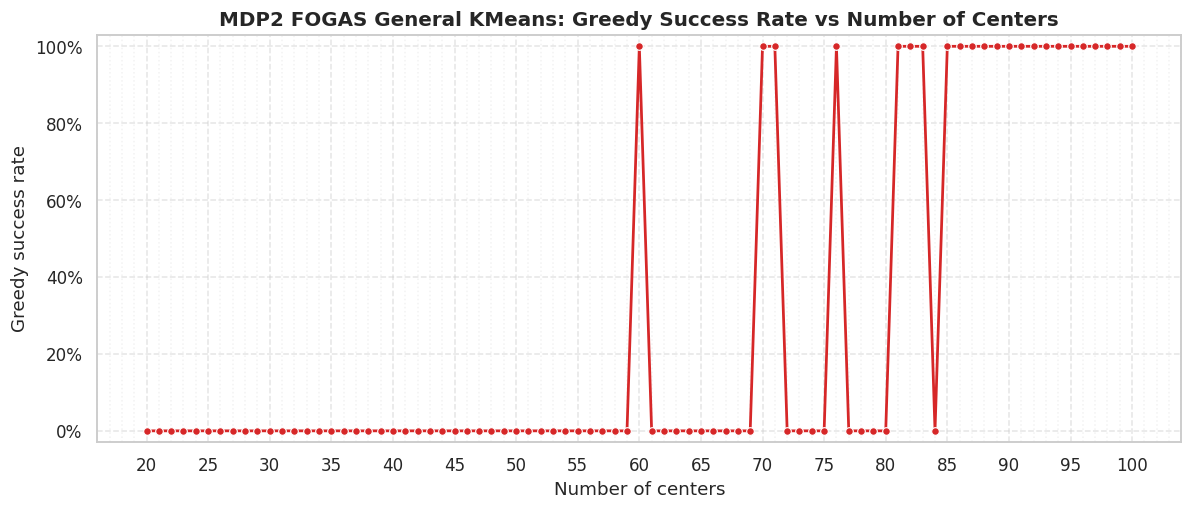

In [6]:
# ── Plot MDP2 FOGAS General KMeans Sweep: Greedy Success Rate ─────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter, MultipleLocator

CSV_PATH = RESULTS_DIR / "mdp2_general_kmeans_center_sweep_fogas.csv"

df_centers = pd.read_csv(CSV_PATH)

if "status" in df_centers.columns:
    df_centers = df_centers[df_centers["status"].eq("ok")].copy()

df_centers["num_centers"] = pd.to_numeric(df_centers["num_centers"], errors="coerce")
df_centers["greedy_success_rate"] = pd.to_numeric(
    df_centers["greedy_success_rate"],
    errors="coerce",
)

df_centers = df_centers.dropna(
    subset=["num_centers", "greedy_success_rate"]
).copy()

df_centers = df_centers.sort_values("num_centers")

print(f"Loaded {len(df_centers)} successful rows from: {CSV_PATH}")
display(df_centers.head())

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

fig, ax = plt.subplots(figsize=(11, 4.8))

sns.lineplot(
    data=df_centers,
    x="num_centers",
    y="greedy_success_rate",
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="tab:red",
    ax=ax,
)

ax.set_title("MDP2 FOGAS General KMeans: Greedy Success Rate vs Number of Centers", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of centers")
ax.set_ylabel("Greedy success rate")

ax.set_ylim(-0.03, 1.03)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", linestyle="--", alpha=0.5)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)

plt.tight_layout()
plt.show()

# Data analysis

The coverage ratio $ \|\lambda_{\pi^*}\|_{\Lambda_n^{-1}}^2 $ measures how much of the "feature mass" required by the optimal policy $\pi^*$ is supported by the directions spanned by the dataset. In the context of the FOGAS framework, $\lambda_{\pi^*}$ represents the expected feature vectors generated by the optimal policy. Using the Eigen-Decomposition of the empirical feature covariance matrix $\Lambda_n$, we can visualize this. Let

$$
\Lambda_n = \sum_{j=1}^d \sigma_j u_j u_j^\top,
$$

where $u_j$ are the principal directions of your dataset in the RBF feature space and $\sigma_j$ are the amounts of data (eigenvalues) in those directions. The coverage ratio becomes:

$$
\|\lambda_{\pi^*}\|_{\Lambda_n^{-1}}^2
=
\sum_{j=1}^d
\frac{\langle \lambda_{\pi^*}, u_j \rangle^2}{\sigma_j}.
$$

Alignment-based coverage with RBFs means that for every direction $u_j$ where the optimal policy has a high occupancy projection, the dataset must have a corresponding high eigenvalue $\sigma_j$. This requires that the data samples sufficiently activate the specific RBF kernels that characterize the optimal policy's trajectory.

One major difference is that RBF features allow for *interpolated coverage*, which is a significant advantage over the one-hot tabular setting. In the tabular case, if a specific state-action pair has zero counts ($N(x,a) = 0$), the coverage ratio can blow up, mitigated only by the regularization parameter $\beta$.

With RBFs, if the dataset contains samples $(X_i, A_i)$ that are near an optimal pair $(x,a)$, the RBF activations will overlap due to their radial nature. This means the dataset provides "partial coverage" for nearby states through the feature correlation inherent in the RBF map. This allows the algorithm to learn about regions of the state-space not explicitly present in the data, potentially resulting in a lower (better) coverage ratio and improved sample complexity compared to a tabular model with the same sparse data.


### GRID search FQI - ordered

Given an offline batch dataset $\mathcal{D}={(x_i,a_i,r_i,x_i')}_{i=1}^n$, this version of (linear) FQI does:

1. **Build targets using current Q estimate**
   $$
   y_i^{(k)} = r_i + \gamma \max_{a'} Q_{\theta_k}(x'_i, a')
   $$

2. **Fit a new Q-function to those targets** by regression on $(x_i,a_i)$
   $$
   \theta_{k+1}^{+}
   = \arg\min_\theta \sum_{i=1}^n \left(y_i^{(k)} - \phi(x_i,a_i)^\top\theta\right)^2 + \lambda|\theta|_2^2
   $$

3. (Optional) **soft update**:
   $$
   \theta_{k+1} = \tau,\theta_k + (1-\tau),\theta_{k+1}^{+}
   $$

We study first of all minimum of centers needed to be able to represent linearly the q function. We used the oracle model FQI with the true Optimal Bellman Operator and $Q^*$, doing the linear (ridge) regression using:
$$y(s,a) = r(s,a) + \gamma \sum_{s'} P(s'|s,a) \max_{a'} Q^*(s', a')$$

In [53]:
# =============================================================================
# FQI CLEAN: EXHAUSTIVE GENERAL KMEANS SEARCH, 100 down to 30 centers
# =============================================================================

RIDGES = [1e-6, 1e-4, 1e-2, 0.1, 1.0, 10.0]
SIGMA_MULTS = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

K_ITERS = 4000
TAU = 0.2

START_CENTERS = 100
END_CENTERS = 30

MAX_STEPS = 40

RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "10grid_rbf"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = RESULTS_DIR / "fqi_general_kmeans_exhaustive_search.csv"


def reaches_goal_clean(solver_fqi, mdp_i, planner_i, max_steps=40, goal_s=99):
    """
    Simulates the learned greedy FQI policy and checks if the goal state is visited.
    Uses FOGASEvaluator because fqi has no separate evaluator.
    """
    evaluator = FOGASEvaluator(
        solver=solver_fqi,
        mdp=mdp_i,
        planner=planner_i,
    )

    traj = evaluator.simulate_trajectory(
        policy_mode="greedy",
        max_steps=max_steps,
        goal_state=goal_s,
        terminal_states=terminal_states,
        seed=seed,
    )

    if not traj:
        return False

    visited = {
        int(step["state"])
        for step in traj
    } | {
        int(step["next_state"])
        for step in traj
    }

    return int(goal_s) in visited


def build_general_kmeans_phi_closure(n_centers, sigma_mult):
    """
    Adapter around your build_general_kmeans_features(...).

    Matches old FQI search:
    - all grid states included, including walls,
    - normalized RBFs,
    - no indicators,
    - no anchors,
    - no bias in the old FQI version.

    NOTE:
    Your build_general_kmeans_features includes a bias.
    If you want exact old FQI parity, set include_bias=False in a variant.
    This version keeps your current FOGAS-style general_kmeans feature:
    RBFs + bias.
    """
    features = build_general_kmeans_features(
        num_centers=n_centers,
        sigma_scale=sigma_mult,
        excluded_states=None,
        normalize_rbf=True,
        k=2,
    )

    centers_i = features["centers"]
    base_sigma_i = features["base_sigma"]
    sigma_i = features["sigma"]
    phi_state_i = features["phi_state"]
    phi_i = features["phi"]

    d_i = int(phi_i(states[0], actions[0]).shape[0])

    return centers_i, base_sigma_i, sigma_i, phi_state_i, phi_i, d_i


def try_config_kmeans_clean(n_centers, ridge, sigma_mult):
    start_time = time.perf_counter()

    row = {
        "n_centers": int(n_centers),
        "ridge": float(ridge),
        "sigma_mult": float(sigma_mult),
        "base_sigma": None,
        "sigma": None,
        "feature_dim": None,
        "converged": False,
        "status": "ok",
        "error": "",
        "elapsed_seconds": None,
    }

    try:
        centers_i, base_sigma_i, sigma_i, _, phi_i, d_i = build_general_kmeans_phi_closure(
            n_centers=n_centers,
            sigma_mult=sigma_mult,
        )

        row["base_sigma"] = float(base_sigma_i)
        row["sigma"] = float(sigma_i)
        row["feature_dim"] = int(d_i)

        mdp_i = DiscreteMDP(
            states=states,
            actions=actions,
            gamma=gamma,
            x0=x0,
            r=r,
            P=P,
            terminal_states=terminal_states,
        )

        planner_i = Planner(mdp_i)

        solver_i = FQISolver(
            mdp=mdp_i,
            phi=phi_i,
            planner=planner_i,
            use_optimal_target_backup=True,
            device=device,
            seed=seed,
            ridge=ridge,
        )

        solver_i.run(
            K=K_ITERS,
            tau=TAU,
            verbose=False,
        )

        row["converged"] = reaches_goal_clean(
            solver_fqi=solver_i,
            mdp_i=mdp_i,
            planner_i=planner_i,
            max_steps=MAX_STEPS,
            goal_s=goal,
        )

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = repr(exc)
        row["converged"] = False

    finally:
        row["elapsed_seconds"] = float(time.perf_counter() - start_time)

    return row


# =============================================================================
# MAIN SEARCH LOOP: Per-center early exit, full center range sweep
# =============================================================================

search_log = []
summary_results = {}

for n in range(START_CENTERS, END_CENTERS - 1, -1):
    print(f"\n[n_centers={n}] Scanning hyperparams...")
    found_for_n = False

    for ridge, sm in itertools.product(RIDGES, SIGMA_MULTS):
        row = try_config_kmeans_clean(
            n_centers=n,
            ridge=ridge,
            sigma_mult=sm,
        )

        search_log.append(row)
        pd.DataFrame(search_log).to_csv(OUTPUT_CSV, index=False)

        if row["status"] != "ok":
            print(
                f"  ERROR: ridge={ridge:.0e}, sigma_mult={sm:.2f} | "
                f"{row['error']} | time={row['elapsed_seconds']:.1f}s"
            )
            continue

        if row["converged"]:
            print(
                f"  Converged: ridge={ridge:.0e}, sigma_mult={sm:.2f} | "
                f"d={row['feature_dim']} | "
                f"sigma={row['sigma']:.6f} | "
                f"time={row['elapsed_seconds']:.1f}s"
            )
            found_for_n = True
            break

    summary_results[n] = found_for_n

    if not found_for_n:
        print("  Failed for all hyperparams.")


# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 30)
print("EXHAUSTIVE SEARCH SUMMARY")
print("=" * 30)

for n, success in sorted(summary_results.items(), reverse=True):
    status = "SUCCESS" if success else "FAILED"
    print(f"Centers: {n:3} | {status}")

df_results = pd.DataFrame(search_log)
df_results.to_csv(OUTPUT_CSV, index=False)

print(f"\nSaved FQI search results to: {OUTPUT_CSV}")


[n_centers=100] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.05 | d=404 | sigma=0.005556 | time=0.4s

[n_centers=99] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.05 | d=400 | sigma=0.005562 | time=0.4s

[n_centers=98] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.05 | d=396 | sigma=0.005569 | time=0.4s

[n_centers=97] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.05 | d=392 | sigma=0.005576 | time=0.3s

[n_centers=96] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.10 | d=388 | sigma=0.011166 | time=0.3s

[n_centers=95] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.10 | d=384 | sigma=0.011194 | time=0.3s

[n_centers=94] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.20 | d=380 | sigma=0.022390 | time=0.3s

[n_centers=93] Scanning hyperparams...
  Converged: ridge=1e-06, sigma_mult=0.10 | d=376 | sigma=0.011182 | time=0.3s

[n_centers=92] Scanning hyperparams...
  Conve

Loaded 1797 successful search rows from: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/10grid_rbf/fqi_general_kmeans_exhaustive_search.csv


,n_centers,success,tried_configs,best_ridge,best_sigma_mult,success_rate
0,30,False,42,NaN,NaN,0.0
1,31,False,42,NaN,NaN,0.0
2,32,False,42,NaN,NaN,0.0
3,33,False,42,NaN,NaN,0.0
4,34,False,42,NaN,NaN,0.0


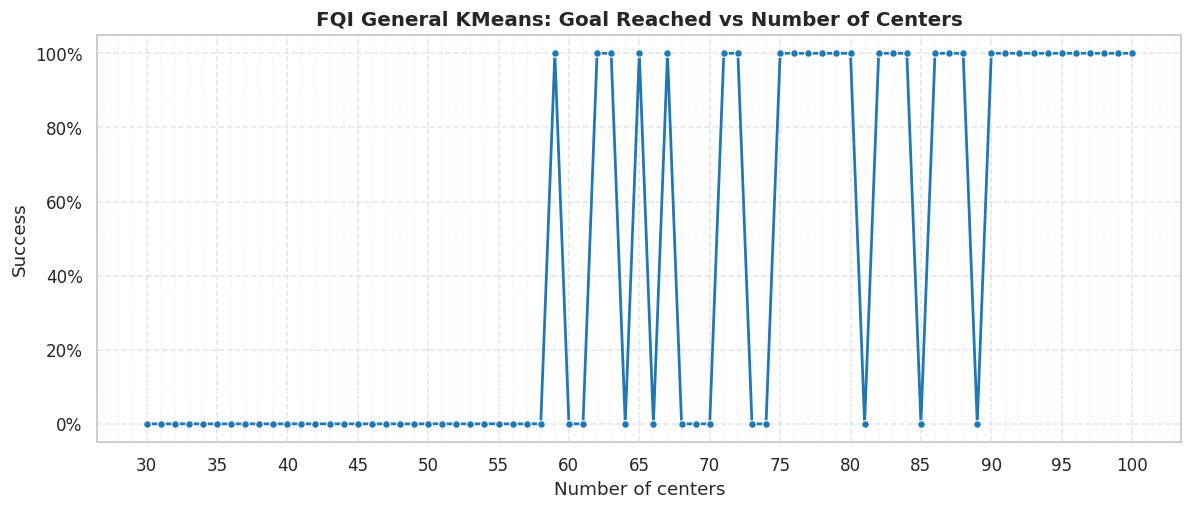

In [5]:
# ── Plot FQI General KMeans Search: Success by Number of Centers ──────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter, MultipleLocator

CSV_PATH = RESULTS_DIR / "fqi_general_kmeans_exhaustive_search.csv"

df_fqi = pd.read_csv(CSV_PATH)

if "status" in df_fqi.columns:
    df_fqi = df_fqi[df_fqi["status"].eq("ok")].copy()

df_fqi["n_centers"] = pd.to_numeric(df_fqi["n_centers"], errors="coerce")
df_fqi["converged"] = df_fqi["converged"].astype(bool)

df_fqi = df_fqi.dropna(subset=["n_centers", "converged"]).copy()

# One row per center: did any hyperparameter config converge?
df_success = (
    df_fqi.groupby("n_centers", as_index=False)
    .agg(
        success=("converged", "max"),
        tried_configs=("converged", "size"),
    )
    .sort_values("n_centers")
)

# First successful hyperparameter setting per n_centers, if any
df_best = (
    df_fqi[df_fqi["converged"]]
    .sort_values(["n_centers", "elapsed_seconds"])
    .groupby("n_centers", as_index=False)
    .first()[["n_centers", "ridge", "sigma_mult"]]
    .rename(
        columns={
            "ridge": "best_ridge",
            "sigma_mult": "best_sigma_mult",
        }
    )
)

df_success = df_success.merge(df_best, on="n_centers", how="left")
df_success["success_rate"] = df_success["success"].astype(float)

print(f"Loaded {len(df_fqi)} successful search rows from: {CSV_PATH}")
display(df_success.head())

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

fig, ax = plt.subplots(figsize=(11, 4.8))

sns.lineplot(
    data=df_success,
    x="n_centers",
    y="success_rate",
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="tab:blue",
    ax=ax,
)

ax.set_title("FQI General KMeans: Goal Reached vs Number of Centers", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of centers")
ax.set_ylabel("Success")

ax.set_ylim(-0.05, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", linestyle="--", alpha=0.5)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)

plt.tight_layout()
plt.show()

Now, lets see with the minimum possible number of centers where the oracle converges, if the "semi" oracle converges too. For that, We will use another model that does the boostrapping but without the dataset, still using the true Bellman Optimal Operator:

$$y_{k+1}(s,a) = r(s,a) + \gamma \sum_{s'} P(s'|s,a) \max_{a'} Q_{\theta_k}(s', a')$$

In [54]:
# =============================================================================
# MODEL-BASED FQI CLEAN SEARCH: Sweep TAU for Fixed General KMeans Features
# =============================================================================

# --- FIXED CONFIGURATION ---
FIXED_N_CENTERS = 71
FIXED_SIGMA_SCALE = 0.1
FIXED_RIDGE = 1e-6

# --- SWEEP PARAMETERS ---
TAUS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0]
K_ITERS = 4000
MAX_STEPS = 40


# 1. Pre-build the fixed features
fixed_features = build_general_kmeans_features(
    num_centers=FIXED_N_CENTERS,
    sigma_scale=FIXED_SIGMA_SCALE,
    excluded_states=None,
    normalize_rbf=True,
    k=2,
)

centers_tau = fixed_features["centers"]
base_sigma_tau = fixed_features["base_sigma"]
sigma_tau = fixed_features["sigma"]
phi_tau = fixed_features["phi"]

d_tau = int(phi_tau(states[0], actions[0]).shape[0])

print(f"Fixed Features: centers={FIXED_N_CENTERS}, sigma_scale={FIXED_SIGMA_SCALE}")
print(f"  base_sigma = {float(base_sigma_tau):.6f}")
print(f"  sigma = {float(sigma_tau):.6f}")
print(f"  feature dimension = {d_tau}")


def try_tau_config_clean(tau_val):
    start_time = time.perf_counter()

    row = {
        "tau": float(tau_val),
        "n_centers": int(FIXED_N_CENTERS),
        "sigma_scale": float(FIXED_SIGMA_SCALE),
        "base_sigma": float(base_sigma_tau),
        "sigma": float(sigma_tau),
        "ridge": float(FIXED_RIDGE),
        "feature_dim": int(d_tau),
        "reached_goal": False,
        "success_rate": None,
        "greedy_avg_reward": None,
        "status": "ok",
        "error": "",
        "elapsed_seconds": None,
    }

    try:
        mdp_i = DiscreteMDP(
            states=states,
            actions=actions,
            gamma=gamma,
            x0=x0,
            r=r,
            P=P,
            terminal_states=terminal_states,
        )

        planner_i = Planner(mdp_i)

        solver_i = FQISolver(
            mdp=mdp_i,
            phi=phi_tau,
            planner=planner_i,
            use_model_based_backup=True,
            use_optimal_target_backup=False,
            device=device,
            seed=seed,
            ridge=FIXED_RIDGE,
        )

        solver_i.run(
            K=K_ITERS,
            tau=tau_val,
            verbose=False,
        )

        evaluator_i = FOGASEvaluator(
            solver=solver_i,
            mdp=mdp_i,
            planner=planner_i,
        )

        success_rate = evaluator_i.success_rate(
            goal_state=goal,
            policy_mode="greedy",
            num_trajectories=1,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        greedy_avg_reward = evaluator_i.average_return(
            policy_mode="greedy",
            num_trajectories=1,
            max_steps=MAX_STEPS,
            seed=seed,
            terminal_states=terminal_states,
        )["policy"]

        row["success_rate"] = float(success_rate)
        row["reached_goal"] = bool(success_rate >= 1.0)
        row["greedy_avg_reward"] = float(greedy_avg_reward)

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = repr(exc)

    finally:
        row["elapsed_seconds"] = float(time.perf_counter() - start_time)

    return row


# =============================================================================
# MAIN TAU SWEEP LOOP
# =============================================================================

tau_log = []

for t_val in TAUS:
    print(f"Testing tau={t_val:4} ...", end=" ")

    row = try_tau_config_clean(t_val)
    tau_log.append(row)

    if row["status"] != "ok":
        print(f"ERROR | {row['error']}")
    elif row["reached_goal"]:
        print(
            f"REACHED GOAL | "
            f"success_rate={row['success_rate']:.2f} | "
            f"greedy_avg_reward={row['greedy_avg_reward']:.6f} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )
    else:
        print(
            f"FAILED | "
            f"success_rate={row['success_rate']:.2f} | "
            f"greedy_avg_reward={row['greedy_avg_reward']:.6f} | "
            f"time={row['elapsed_seconds']:.1f}s"
        )


df_tau = pd.DataFrame(tau_log)

print("\n--- Tau Sweep Results ---")
print(df_tau[[
    "tau",
    "reached_goal",
    "success_rate",
    "greedy_avg_reward",
    "elapsed_seconds",
]])

Fixed Features: centers=71, sigma_scale=0.1
  base_sigma = 0.114815
  sigma = 0.011481
  feature dimension = 288
Testing tau=0.01 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau=0.05 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 0.1 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 0.2 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 0.3 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 0.4 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 0.5 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 0.7 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.8s
Testing tau= 0.9 ... REACHED GOAL | success_rate=1.00 | greedy_avg_reward=-0.822741 | time=0.6s
Testing tau= 1.0 ... FA

Now, knowing that FQI with that features should work:

In [57]:
# --- Reconstruct winning FQI-style features with clean helper ---
winning_features = build_general_kmeans_features(
    num_centers=71,
    sigma_scale=0.1,
    excluded_states=None,
    normalize_rbf=True,
    k=2,
)

centers_win = winning_features["centers"]
sigma_win = winning_features["sigma"]
phi_win = winning_features["phi"]

d_win = int(phi_win(states[0], actions[0]).shape[0])

mdp_final = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x0,
    r=r,
    P=P,
    terminal_states=terminal_states,
)

planner_final = Planner(mdp_final)

print(f"Winning features: centers={len(centers_win)}")
print(f"  sigma = {float(sigma_win):.6f}")
print(f"  d = {d_win}")

Winning features: centers=71
  sigma = 0.011481
  d = 288


In [58]:
solver_fqi_win = FQISolver(
    mdp=mdp_final,
    phi=phi_win,
    csv_path=str(DATASET_PATH),
    planner=planner_final,
    device=device,
    seed=seed,
    ridge=1e-6,
    augment_terminal_transitions=True,
)

solver_fqi_win.run(
    K=4000,
    tau=0.2,
    verbose=True,
)

evaluator_fqi_win = FOGASEvaluator(
    solver=solver_fqi_win,
    mdp=mdp_final,
    planner=planner_final,
)

FQI: 100%|███████████| 4000/4000 [00:01<00:00, 2189.39it/s, theta_norm=197.3025]


In [59]:
greedy_avg_reward = evaluator_fqi_win.average_return(
    policy_mode="greedy",
    num_trajectories=1,
    max_steps=50,
    seed=seed,
    terminal_states=terminal_states,
)

greedy_success_rate = evaluator_fqi_win.success_rate(
    goal_state=goal,
    policy_mode="greedy",
    num_trajectories=1,
    max_steps=50,
    seed=seed,
    terminal_states=terminal_states,
)

print("FQI winning-feature evaluation")
print(f"  greedy_avg_reward = {greedy_avg_reward['policy']:.6f}")
print(f"  greedy_success_rate = {greedy_success_rate['policy']:.2f}")

FQI winning-feature evaluation
  greedy_avg_reward = -0.822741
  greedy_success_rate = 1.00
